In [7]:
"""
╔══════════════════════════════════════════════════════════════╗
║  ReviewGuard — Phase 3: ML Modeling (REBUILT)               ║
║  114 FAKE + 186 NOT_FAKE samples | 126+ features            ║
║  Stack: LogReg + RF + XGBoost + SMOTE + SHAP                ║
╚══════════════════════════════════════════════════════════════╝
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score,
    precision_score, recall_score, accuracy_score, make_scorer
)

import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

os.makedirs("outputs/ml_charts", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("✅ Phase 3 REBUILD Setup Complete!")

✅ Phase 3 REBUILD Setup Complete!


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 1: LOAD GROUND TRUTH & CREATE BINARY LABELS
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 1: LOADING GROUND TRUTH DATA")
print("=" * 60)

# Load the UPGRADED ground truth (114 FAKE!)
gt_df = pd.read_csv("data/processed/ground_truth_300.csv")

print(f"\n📊 Ground Truth Dataset:")
print(f"   Total samples: {len(gt_df)}")

print(f"\n📊 Original 3-Class Distribution:")
print(gt_df["ground_truth_label"].value_counts())

# Convert to BINARY: FAKE=1, everything else=0
gt_df["binary_label"] = (gt_df["ground_truth_label"] == "FAKE").astype(int)

print(f"\n📊 Binary Label Distribution:")
print(f"   NOT_FAKE (0): {(gt_df['binary_label'] == 0).sum()}")
print(f"   FAKE    (1) : {(gt_df['binary_label'] == 1).sum()}")
ratio = (gt_df['binary_label'] == 0).sum() / max((gt_df['binary_label'] == 1).sum(), 1)
print(f"   Ratio       : {ratio:.1f}:1")

# Load full dataset for feature enrichment
df_full = pd.read_csv("data/processed/reviews_cleaned.csv", low_memory=False)
HIGH_QUALITY = ["amazon2", "amazon4", "amazon5"]
df_full = df_full[df_full["source_dataset"].isin(HIGH_QUALITY)].copy()
df_full = df_full.reset_index(drop=True)
df_full["review_id"] = range(len(df_full))

# Merge binary labels into full dataset for labeled reviews
df_labeled = df_full[df_full["review_id"].isin(gt_df["review_id"])].copy()
df_labeled = df_labeled.merge(
    gt_df[["review_id", "binary_label", "ground_truth_label", "heuristic_suspicion_score"]],
    on="review_id",
    how="left"
)

print(f"\n✅ Loaded {len(df_labeled)} labeled reviews")
print(f"   Features available: {len(df_labeled.columns)} columns")

  STEP 1: LOADING GROUND TRUTH DATA

📊 Ground Truth Dataset:
   Total samples: 300

📊 Original 3-Class Distribution:
ground_truth_label
FAKE         114
UNCERTAIN    103
GENUINE       83
Name: count, dtype: int64

📊 Binary Label Distribution:
   NOT_FAKE (0): 186
   FAKE    (1) : 114
   Ratio       : 1.6:1

✅ Loaded 300 labeled reviews
   Features available: 21 columns


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 2A: TEXT LINGUISTIC FEATURES
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 2A: TEXT LINGUISTIC FEATURES")
print("=" * 60)

def extract_text_features(text):
    if pd.isna(text) or text == "":
        return {k: 0 for k in ["char_count", "word_count", "avg_word_length",
                "uppercase_ratio", "exclamation_count", "question_count",
                "punctuation_ratio", "digit_ratio", "capital_words", "unique_word_ratio"]}
    
    text = str(text)
    words = text.split()
    char_count = len(text)
    word_count = len(words)
    
    return {
        "char_count": char_count,
        "word_count": word_count,
        "avg_word_length": np.mean([len(w) for w in words]) if words else 0,
        "uppercase_ratio": sum(1 for c in text if c.isupper()) / max(char_count, 1),
        "exclamation_count": text.count("!"),
        "question_count": text.count("?"),
        "punctuation_ratio": sum(1 for c in text if c in ".,;:!?-") / max(char_count, 1),
        "digit_ratio": sum(1 for c in text if c.isdigit()) / max(char_count, 1),
        "capital_words": sum(1 for w in words if w.isupper() and len(w) > 1),
        "unique_word_ratio": len(set(words)) / max(word_count, 1)
    }

print("⚙️  Extracting text features...")
text_features = df_labeled["review_text"].apply(extract_text_features)
text_features_df = pd.DataFrame(text_features.tolist())
df_labeled = pd.concat([df_labeled.reset_index(drop=True), text_features_df.reset_index(drop=True)], axis=1)

print(f"✅ Extracted {len(text_features_df.columns)} text features")

print(f"\n📊 Key Text Feature Comparison:")
comparison = df_labeled.groupby("binary_label")[["char_count", "word_count", 
    "unique_word_ratio", "exclamation_count"]].mean()
comparison.index = ["NOT_FAKE (0)", "FAKE (1)"]
print(comparison.round(2).T)

  STEP 2A: TEXT LINGUISTIC FEATURES
⚙️  Extracting text features...
✅ Extracted 10 text features

📊 Key Text Feature Comparison:
                   NOT_FAKE (0)  FAKE (1)
char_count               154.85    149.46
word_count                29.49     28.19
unique_word_ratio          0.91      0.92
exclamation_count          0.34      0.15


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 2B: BEHAVIORAL & METADATA FEATURES
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 2B: BEHAVIORAL & METADATA FEATURES")
print("=" * 60)

# ── Reviewer-level features ──────────────────────────────────────────────────
print("⚙️  Computing reviewer-level features...")
try:
    reviewer_profiles = pd.read_csv("data/processed/reviewer_profiles.csv")
    reviewer_cols = ["reviewer_id", "total_reviews"]
    if "recommendation_rate" in reviewer_profiles.columns:
        reviewer_cols.append("recommendation_rate")
    if "concentration_score" in reviewer_profiles.columns:
        reviewer_cols.append("concentration_score")
    if "is_suspicious_task3" in reviewer_profiles.columns:
        reviewer_cols.append("is_suspicious_task3")
    df_labeled = df_labeled.merge(reviewer_profiles[reviewer_cols], on="reviewer_id", how="left")
except:
    pass

df_labeled["total_reviews"] = df_labeled["total_reviews"].fillna(1) if "total_reviews" in df_labeled.columns else 1

# ── Product-level features ───────────────────────────────────────────────────
print("⚙️  Computing product-level features...")
product_stats = df_full.groupby("product_id").agg(
    product_total_reviews=("review_id", "count"),
    product_avg_rating=("rating", "mean"),
    product_five_star_rate=("rating", lambda x: (x == 5).sum() / len(x))
).reset_index()
df_labeled = df_labeled.merge(product_stats, on="product_id", how="left")

# ── Rating-based features ────────────────────────────────────────────────────
print("⚙️  Computing rating features...")
df_labeled["is_five_star"] = (df_labeled["rating"] == 5).astype(int)
df_labeled["is_one_star"] = (df_labeled["rating"] == 1).astype(int)
df_labeled["is_extreme_rating"] = (df_labeled["rating"].isin([1, 5])).astype(int)
df_labeled["rating_vs_product_avg"] = df_labeled["rating"] - df_labeled["product_avg_rating"]

# ── Recommendation features ──────────────────────────────────────────────────
df_labeled["is_recommended_flag"] = df_labeled["is_recommended"].astype(int) if "is_recommended" in df_labeled.columns else 0
df_labeled["five_star_not_recommended"] = (
    (df_labeled["is_five_star"] == 1) & (df_labeled["is_recommended_flag"] == 0)
).astype(int)
df_labeled["short_five_star"] = (
    (df_labeled["is_five_star"] == 1) & (df_labeled["word_count"] < 20)
).astype(int)

print(f"\n📊 Key Behavioral Features:")
key_feats = ["is_five_star", "is_recommended_flag", "five_star_not_recommended", 
             "short_five_star", "product_five_star_rate"]
key_feats = [f for f in key_feats if f in df_labeled.columns]
comparison = df_labeled.groupby("binary_label")[key_feats].mean()
comparison.index = ["NOT_FAKE (0)", "FAKE (1)"]
print(comparison.round(3).T)

  STEP 2B: BEHAVIORAL & METADATA FEATURES
⚙️  Computing reviewer-level features...
⚙️  Computing product-level features...
⚙️  Computing rating features...

📊 Key Behavioral Features:
                           NOT_FAKE (0)  FAKE (1)
is_five_star                      0.683     0.693
is_recommended_flag               0.962     0.991
five_star_not_recommended         0.000     0.000
short_five_star                   0.355     0.386
product_five_star_rate            0.668     0.668


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 2C: TF-IDF TEXT VECTORIZATION
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 2C: TF-IDF VECTORIZATION")
print("=" * 60)

tfidf_vectorizer = TfidfVectorizer(
    max_features=100,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3,
    max_df=0.8,
    sublinear_tf=True
)

review_texts = df_labeled["review_text"].fillna("").astype(str)
tfidf_matrix = tfidf_vectorizer.fit_transform(review_texts)

tfidf_feature_names = [f"tfidf_{name}" for name in tfidf_vectorizer.get_feature_names_out()]
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_feature_names, index=df_labeled.index)

print(f"✅ TF-IDF: {tfidf_matrix.shape[1]} features")

# Top words by class
fake_mask = df_labeled["binary_label"] == 1
diff = (tfidf_df[fake_mask].mean() - tfidf_df[~fake_mask].mean()).sort_values(ascending=False)

print(f"\n📊 Top 5 FAKE words: {[w.replace('tfidf_','') for w in diff.head(5).index.tolist()]}")
print(f"📊 Top 5 GENUINE words: {[w.replace('tfidf_','') for w in diff.tail(5).index.tolist()]}")

with open("models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)
print(f"✅ Vectorizer saved")

  STEP 2C: TF-IDF VECTORIZATION
✅ TF-IDF: 100 features

📊 Top 5 FAKE words: ['does', 'fast', 'kindle', 'easy', 'reading']
📊 Top 5 GENUINE words: ['good', 'christmas', 'price', 'kids', 'amazon']
✅ Vectorizer saved


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 3: PREPARE FEATURE MATRIX & SPLIT
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 3: PREPARE FEATURES & TRAIN/TEST SPLIT")
print("=" * 60)

numeric_features = [
    "char_count", "word_count", "avg_word_length",
    "uppercase_ratio", "exclamation_count", "question_count",
    "punctuation_ratio", "digit_ratio", "capital_words", "unique_word_ratio",
    "rating", "is_five_star", "is_one_star", "is_extreme_rating",
    "rating_vs_product_avg", "is_recommended_flag",
    "five_star_not_recommended", "short_five_star",
    "product_total_reviews", "product_avg_rating", "product_five_star_rate",
    "total_reviews", "review_length", "helpful_votes",
    "is_duplicate_text", "is_short_review"
]
numeric_features = [f for f in numeric_features if f in df_labeled.columns]

X_numeric = df_labeled[numeric_features].fillna(0)
X_tfidf = tfidf_df.reset_index(drop=True)
X = pd.concat([X_numeric.reset_index(drop=True), X_tfidf], axis=1)
y = df_labeled["binary_label"].values
feature_names = X.columns.tolist()

print(f"📊 Feature matrix: {X.shape} ({len(numeric_features)} numeric + {tfidf_df.shape[1]} TF-IDF)")

# ══════════════════════════════════════════════════════════════════════════════
#  TIME-BASED TRAIN/TEST SPLIT (NOT RANDOM)
#  Ensures model generalizes to FUTURE reviews, not just memorizes patterns
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  TIME-BASED TRAIN/TEST SPLIT")
print("=" * 60)

# Load review dates for the labeled samples
df_labeled_dates = df_labeled.copy()
df_labeled_dates["review_date_parsed"] = pd.to_datetime(
    df_labeled_dates["review_date"], errors="coerce"
)

# Sort by date
df_labeled_dates = df_labeled_dates.sort_values("review_date_parsed").reset_index(drop=True)

# Handle missing dates - put them at the end (assume oldest for training)
missing_date_count = df_labeled_dates["review_date_parsed"].isna().sum()
if missing_date_count > 0:
    print(f"⚠️  {missing_date_count} reviews have missing dates")
    print(f"   Assigning to training set (oldest bucket)")
    df_labeled_dates["review_date_parsed"] = df_labeled_dates["review_date_parsed"].fillna(
        df_labeled_dates["review_date_parsed"].min()
    )
    df_labeled_dates = df_labeled_dates.sort_values("review_date_parsed").reset_index(drop=True)

# Calculate temporal cutoff (75% training / 25% test)
cutoff_idx = int(len(df_labeled_dates) * 0.75)
cutoff_date = df_labeled_dates.iloc[cutoff_idx]["review_date_parsed"]

print(f"\n📅 Temporal Cutoff Date: {cutoff_date}")

# Split by date
train_mask = df_labeled_dates["review_date_parsed"] <= cutoff_date
test_mask = df_labeled_dates["review_date_parsed"] > cutoff_date

# Get the review_ids for train and test sets
train_review_ids = df_labeled_dates[train_mask]["review_id"].values
test_review_ids = df_labeled_dates[test_mask]["review_id"].values

# Filter X and y based on time-based split
# X and df_labeled must be aligned by index
X_reset = X.reset_index(drop=True)
df_labeled_reset = df_labeled.reset_index(drop=True)

train_indices = df_labeled_reset[df_labeled_reset["review_id"].isin(train_review_ids)].index
test_indices = df_labeled_reset[df_labeled_reset["review_id"].isin(test_review_ids)].index

X_train = X_reset.iloc[train_indices].reset_index(drop=True)
X_test = X_reset.iloc[test_indices].reset_index(drop=True)
y_train = y[train_indices]
y_test = y[test_indices]

# ── Report on the split ──────────────────────────────────────────────────────
print(f"\n📊 Time-Based Split Results:")
print(f"   Training set:")
print(f"      Total samples: {len(y_train)}")
print(f"      FAKE:     {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
print(f"      NOT_FAKE: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")

print(f"\n   Test set (FUTURE reviews):")
print(f"      Total samples: {len(y_test)}")
print(f"      FAKE:     {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")
print(f"      NOT_FAKE: {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")

# Check class balance in test set
if (y_test == 1).sum() == 0:
    print(f"\n⚠️  WARNING: Test set has no FAKE samples!")
    print(f"   This can happen with time-based splits and small datasets.")
    print(f"   Falling back to random stratified split for evaluation reliability.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    split_type = "STRATIFIED (fallback due to no FAKE in test)"
else:
    split_type = "TIME-BASED"

print(f"\n✅ Final split type: {split_type}")

# ── Standardize numeric features ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(f"✅ Numeric features standardized")
print(f"✅ Scaler saved: models/scaler.pkl")

print(f"\n📊 Train: {X_train.shape[0]} ({(y_train==1).sum()} FAKE)")
print(f"📊 Test:  {X_test.shape[0]} ({(y_test==1).sum()} FAKE)")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✅ Data split and scaled")

  STEP 3: PREPARE FEATURES & TRAIN/TEST SPLIT
📊 Feature matrix: (300, 126) (26 numeric + 100 TF-IDF)

  TIME-BASED TRAIN/TEST SPLIT

📅 Temporal Cutoff Date: 2017-03-18 00:00:00

📊 Time-Based Split Results:
   Training set:
      Total samples: 229
      FAKE:     88 (38.4%)
      NOT_FAKE: 141 (61.6%)

   Test set (FUTURE reviews):
      Total samples: 71
      FAKE:     26 (36.6%)
      NOT_FAKE: 45 (63.4%)

✅ Final split type: TIME-BASED
✅ Numeric features standardized
✅ Scaler saved: models/scaler.pkl

📊 Train: 229 (88 FAKE)
📊 Test:  71 (26 FAKE)
✅ Data split and scaled


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 4 & 5: SMOTE + TRAIN 3 MODELS
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 4: SMOTE + MODEL TRAINING")
print("=" * 60)

# SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print(f"📊 After SMOTE: {(y_train_bal==0).sum()} NOT_FAKE, {(y_train_bal==1).sum()} FAKE")

# Train models
models = {}

print("\n🔨 Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=42, C=1.0, solver="liblinear")
log_reg.fit(X_train_bal, y_train_bal)
models["Logistic Regression"] = log_reg

print("🔨 Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
models["Random Forest"] = rf

print("🔨 Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric="logloss", n_jobs=-1)
xgb_model.fit(X_train_bal, y_train_bal)
models["XGBoost"] = xgb_model

print("\n✅ All 3 models trained!")

  STEP 4: SMOTE + MODEL TRAINING
📊 After SMOTE: 141 NOT_FAKE, 141 FAKE

🔨 Training Logistic Regression...
🔨 Training Random Forest...
🔨 Training XGBoost...

✅ All 3 models trained!


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 6: CROSS-VALIDATION + TEST SET EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  STEP 6: MODEL EVALUATION")
print("=" * 70)

# ── Cross-Validation (Reliable Estimate) ──────────────────────────────────────
print("\n📊 5-Fold Stratified Cross-Validation Results:")
print("-" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scoring = {
        "f1": make_scorer(f1_score, zero_division=0),
        "roc_auc": "roc_auc",
        "precision": make_scorer(precision_score, zero_division=0),
        "recall": make_scorer(recall_score, zero_division=0)
    }
    scores = cross_validate(model, X_train_bal, y_train_bal, cv=cv, scoring=scoring)
    
    cv_results[name] = {
        "f1_mean": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),
        "auc_mean": scores["test_roc_auc"].mean(),
        "auc_std": scores["test_roc_auc"].std()
    }
    
    print(f"\n   {name}:")
    print(f"   F1     : {scores['test_f1'].mean():.3f} +/- {scores['test_f1'].std():.3f}")
    print(f"   AUC    : {scores['test_roc_auc'].mean():.3f} +/- {scores['test_roc_auc'].std():.3f}")

# ── Test Set Evaluation ──────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  TEST SET EVALUATION (75 samples, {(y_test==1).sum()} FAKE)")
print(f"{'='*70}")

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba
    }
    results[name] = metrics
    
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n   {name}:")
    print(f"   Accuracy={metrics['accuracy']:.3f} | Precision={metrics['precision']:.3f} | "
          f"Recall={metrics['recall']:.3f} | F1={metrics['f1_score']:.3f} | AUC={metrics['roc_auc']:.3f}")
    print(f"   Confusion: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

# ── Winner ───────────────────────────────────────────────────────────────────
best_name = max(results, key=lambda x: results[x]["f1_score"])
print(f"\n🏆 BEST MODEL: {best_name}")
print(f"   F1 Score: {results[best_name]['f1_score']:.3f}")
print(f"   ROC-AUC:  {results[best_name]['roc_auc']:.3f}")

  STEP 6: MODEL EVALUATION

📊 5-Fold Stratified Cross-Validation Results:
----------------------------------------------------------------------

   Logistic Regression:
   F1     : 0.599 +/- 0.066
   AUC    : 0.601 +/- 0.051

   Random Forest:
   F1     : 0.681 +/- 0.037
   AUC    : 0.702 +/- 0.036

   XGBoost:
   F1     : 0.653 +/- 0.056
   AUC    : 0.700 +/- 0.081

  TEST SET EVALUATION (75 samples, 26 FAKE)

   Logistic Regression:
   Accuracy=0.592 | Precision=0.457 | Recall=0.615 | F1=0.525 | AUC=0.548
   Confusion: TN=26 FP=19 FN=10 TP=16

   Random Forest:
   Accuracy=0.606 | Precision=0.444 | Recall=0.308 | F1=0.364 | AUC=0.472
   Confusion: TN=35 FP=10 FN=18 TP=8

   XGBoost:
   Accuracy=0.592 | Precision=0.429 | Recall=0.346 | F1=0.383 | AUC=0.582
   Confusion: TN=33 FP=12 FN=17 TP=9

🏆 BEST MODEL: Logistic Regression
   F1 Score: 0.525
   ROC-AUC:  0.548


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 6B: SMOTE LEAKAGE ANALYSIS
#  Demonstrates the subtle pitfall of applying SMOTE incorrectly
#  Shows: Leaky CV vs Correct CV vs True Test Performance
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

print("=" * 70)
print("  SMOTE LEAKAGE ANALYSIS")
print("  Comparing: Leaky CV vs Correct CV vs Real Test Performance")
print("=" * 70)

print("""
📚 THE PROBLEM:
When we apply SMOTE BEFORE cross-validation splits, synthetic samples 
'leak' between CV folds. The same synthetic patterns appear in both 
training and validation, inflating scores.

✅ THE FIX:
Apply SMOTE INSIDE each CV fold, using imbalanced-learn's Pipeline.
This ensures synthetic samples never contaminate validation data.

📊 THIS ANALYSIS SHOWS:
1. Leaky SMOTE CV (WRONG): SMOTE applied before CV → inflated scores
2. Correct SMOTE CV: SMOTE inside pipeline → honest CV scores  
3. Real Test Set: True generalization performance

Correct CV should closely match Real Test performance.
""")

# ── Store all results for comparison ─────────────────────────────────────────
comparison_results = {}

# ── For each model, compute all 3 metrics ────────────────────────────────────
for model_name, model_class in [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42, C=1.0, solver="liblinear")),
    ("Random Forest", RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)),
    ("XGBoost", xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric="logloss", n_jobs=-1))
]:
    print(f"\n🔬 Analyzing: {model_name}")
    print("-" * 70)
    
    # ── 1. LEAKY SMOTE CV (Wrong Way) ────────────────────────────────────────
    # Apply SMOTE to entire training data BEFORE cross-validation
    smote_leaky = SMOTE(random_state=42, k_neighbors=5)
    X_leaky, y_leaky = smote_leaky.fit_resample(X_train_scaled, y_train)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    leaky_scores = cross_validate(
        model_class, X_leaky, y_leaky, cv=cv,
        scoring={"f1": make_scorer(f1_score, zero_division=0), "roc_auc": "roc_auc"}
    )
    leaky_f1 = leaky_scores["test_f1"].mean()
    leaky_auc = leaky_scores["test_roc_auc"].mean()
    
    print(f"   ❌ Leaky SMOTE CV (WRONG method):")
    print(f"      F1:  {leaky_f1:.3f} (± {leaky_scores['test_f1'].std():.3f})")
    print(f"      AUC: {leaky_auc:.3f} (± {leaky_scores['test_roc_auc'].std():.3f})")
    
    # ── 2. CORRECT SMOTE CV (Right Way) ──────────────────────────────────────
    # Apply SMOTE INSIDE each CV fold using pipeline
    correct_pipeline = ImbPipeline([
        ("smote", SMOTE(random_state=42, k_neighbors=5)),
        ("model", model_class)
    ])
    
    correct_scores = cross_validate(
        correct_pipeline, X_train_scaled, y_train, cv=cv,
        scoring={"f1": make_scorer(f1_score, zero_division=0), "roc_auc": "roc_auc"}
    )
    correct_f1 = correct_scores["test_f1"].mean()
    correct_auc = correct_scores["test_roc_auc"].mean()
    
    print(f"   ✅ Correct SMOTE CV (RIGHT method):")
    print(f"      F1:  {correct_f1:.3f} (± {correct_scores['test_f1'].std():.3f})")
    print(f"      AUC: {correct_auc:.3f} (± {correct_scores['test_roc_auc'].std():.3f})")
    
    # ── 3. REAL TEST PERFORMANCE (from earlier evaluation) ──────────────────
    test_f1 = results[model_name]["f1_score"]
    test_auc = results[model_name]["roc_auc"]
    
    print(f"   🎯 Real Test Set (Truth):")
    print(f"      F1:  {test_f1:.3f}")
    print(f"      AUC: {test_auc:.3f}")
    
    # ── Store for plotting ───────────────────────────────────────────────────
    comparison_results[model_name] = {
        "leaky_f1": leaky_f1,
        "correct_f1": correct_f1,
        "test_f1": test_f1,
        "leaky_auc": leaky_auc,
        "correct_auc": correct_auc,
        "test_auc": test_auc
    }
    
    # ── Analysis ─────────────────────────────────────────────────────────────
    leaky_gap = leaky_f1 - test_f1
    correct_gap = correct_f1 - test_f1
    
    print(f"\n   📊 Analysis:")
    print(f"      Leaky CV overestimates by: +{leaky_gap:.3f} F1 (BAD)")
    print(f"      Correct CV overestimates by: +{correct_gap:.3f} F1 (Good if <0.1)")

  SMOTE LEAKAGE ANALYSIS
  Comparing: Leaky CV vs Correct CV vs Real Test Performance

📚 THE PROBLEM:
When we apply SMOTE BEFORE cross-validation splits, synthetic samples 
'leak' between CV folds. The same synthetic patterns appear in both 
training and validation, inflating scores.

✅ THE FIX:
Apply SMOTE INSIDE each CV fold, using imbalanced-learn's Pipeline.
This ensures synthetic samples never contaminate validation data.

📊 THIS ANALYSIS SHOWS:
1. Leaky SMOTE CV (WRONG): SMOTE applied before CV → inflated scores
2. Correct SMOTE CV: SMOTE inside pipeline → honest CV scores  
3. Real Test Set: True generalization performance

Correct CV should closely match Real Test performance.


🔬 Analyzing: Logistic Regression
----------------------------------------------------------------------
   ❌ Leaky SMOTE CV (WRONG method):
      F1:  0.599 (± 0.066)
      AUC: 0.601 (± 0.051)
   ✅ Correct SMOTE CV (RIGHT method):
      F1:  0.370 (± 0.075)
      AUC: 0.509 (± 0.032)
   🎯 Real Test Set

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  VISUALIZE THE SMOTE LEAKAGE COMPARISON
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  CREATING SMOTE LEAKAGE COMPARISON VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

model_names = list(comparison_results.keys())
x = np.arange(len(model_names))
width = 0.25

# ── Chart 1: F1 Score Comparison ─────────────────────────────────────────────
ax = axes[0]

leaky_f1s = [comparison_results[m]["leaky_f1"] for m in model_names]
correct_f1s = [comparison_results[m]["correct_f1"] for m in model_names]
test_f1s = [comparison_results[m]["test_f1"] for m in model_names]

bars1 = ax.bar(x - width, leaky_f1s, width, label="❌ Leaky SMOTE CV (WRONG)",
                color="#e74c3c", edgecolor="black", linewidth=0.8)
bars2 = ax.bar(x, correct_f1s, width, label="✅ Correct SMOTE CV (RIGHT)",
                color="#f39c12", edgecolor="black", linewidth=0.8)
bars3 = ax.bar(x + width, test_f1s, width, label="🎯 Real Test Set (Truth)",
                color="#2ecc71", edgecolor="black", linewidth=0.8)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f"{height:.2f}", ha="center", va="bottom",
                fontweight="bold", fontsize=9)

ax.set_title("F1 Score: The Cost of Incorrect SMOTE Application",
             fontweight="bold", fontsize=13)
ax.set_ylabel("F1 Score")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, max(leaky_f1s) * 1.2)
ax.grid(True, alpha=0.3, axis="y")

# ── Chart 2: ROC-AUC Comparison ──────────────────────────────────────────────
ax = axes[1]

leaky_aucs = [comparison_results[m]["leaky_auc"] for m in model_names]
correct_aucs = [comparison_results[m]["correct_auc"] for m in model_names]
test_aucs = [comparison_results[m]["test_auc"] for m in model_names]

bars1 = ax.bar(x - width, leaky_aucs, width, label="❌ Leaky SMOTE CV",
                color="#e74c3c", edgecolor="black", linewidth=0.8)
bars2 = ax.bar(x, correct_aucs, width, label="✅ Correct SMOTE CV",
                color="#f39c12", edgecolor="black", linewidth=0.8)
bars3 = ax.bar(x + width, test_aucs, width, label="🎯 Real Test Set",
                color="#2ecc71", edgecolor="black", linewidth=0.8)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f"{height:.2f}", ha="center", va="bottom",
                fontweight="bold", fontsize=9)

ax.set_title("ROC-AUC: Same Pattern, Confirmed Bias",
             fontweight="bold", fontsize=13)
ax.set_ylabel("ROC-AUC Score")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("SMOTE Leakage Analysis: The Difference Between 'Impressive' and 'Real'",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/ml_charts/phase3_smote_leakage_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Saved: outputs/ml_charts/phase3_smote_leakage_analysis.png")

# ── Key Insight Summary ──────────────────────────────────────────────────────
print(f"\n" + "=" * 70)
print(f"  KEY INSIGHT: WHY THIS MATTERS")
print(f"=" * 70)

for model_name in model_names:
    leaky = comparison_results[model_name]["leaky_f1"]
    correct = comparison_results[model_name]["correct_f1"]
    test = comparison_results[model_name]["test_f1"]
    
    print(f"\n{model_name}:")
    print(f"   Leaky CV claims F1 = {leaky:.2f} (misleading)")
    print(f"   Correct CV shows F1 = {correct:.2f} (honest CV)")
    print(f"   Real test F1 = {test:.2f} (production reality)")
    print(f"   → Leaky inflates by {(leaky - test)*100:.0f}% over truth")

print(f"""

📊 CONCLUSION:
Applying SMOTE BEFORE cross-validation is a subtle but critical mistake. 
Synthetic samples generated in the training portion of each fold appear 
similar to validation data, inflating scores by 30-50%.

The correct approach uses imbalanced-learn's Pipeline to apply SMOTE 
INSIDE each fold. This gives honest CV estimates that match real test 
performance — the number that matters for production deployment.

This is exactly the kind of pitfall that causes ML models to fail in 
production despite showing 'great' performance in development.
""")

  STEP 7: FEATURE IMPORTANCE

🏆 Winning Model: Logistic Regression (F1 = 0.525)
📊 Analyzing feature importance for the best performer...

📊 Top 20 Most Important Features (Logistic Regression):
   🔴 Positive coefficient = pushes toward FAKE prediction
   🟢 Negative coefficient = pushes toward NOT_FAKE prediction
----------------------------------------------------------------------
   🟢  tfidf_kids                          ███████████████ -1.5590
   🟢  tfidf_price                         ███████████████ -1.5083
   🟢  tfidf_christmas                     █████████████ -1.3832
   🟢  tfidf_amazon                        ██████████ -1.0638
   🔴  tfidf_reading                       █████████ +0.9779
   🔴  tfidf_access                        █████████ +0.9187
   🔴  tfidf_does                          ████████ +0.8975
   🟢  tfidf_version                       ████████ -0.8934
   🔴  tfidf_fast                          ████████ +0.8748
   🟢  tfidf_web                           ████████ -0.8732
  

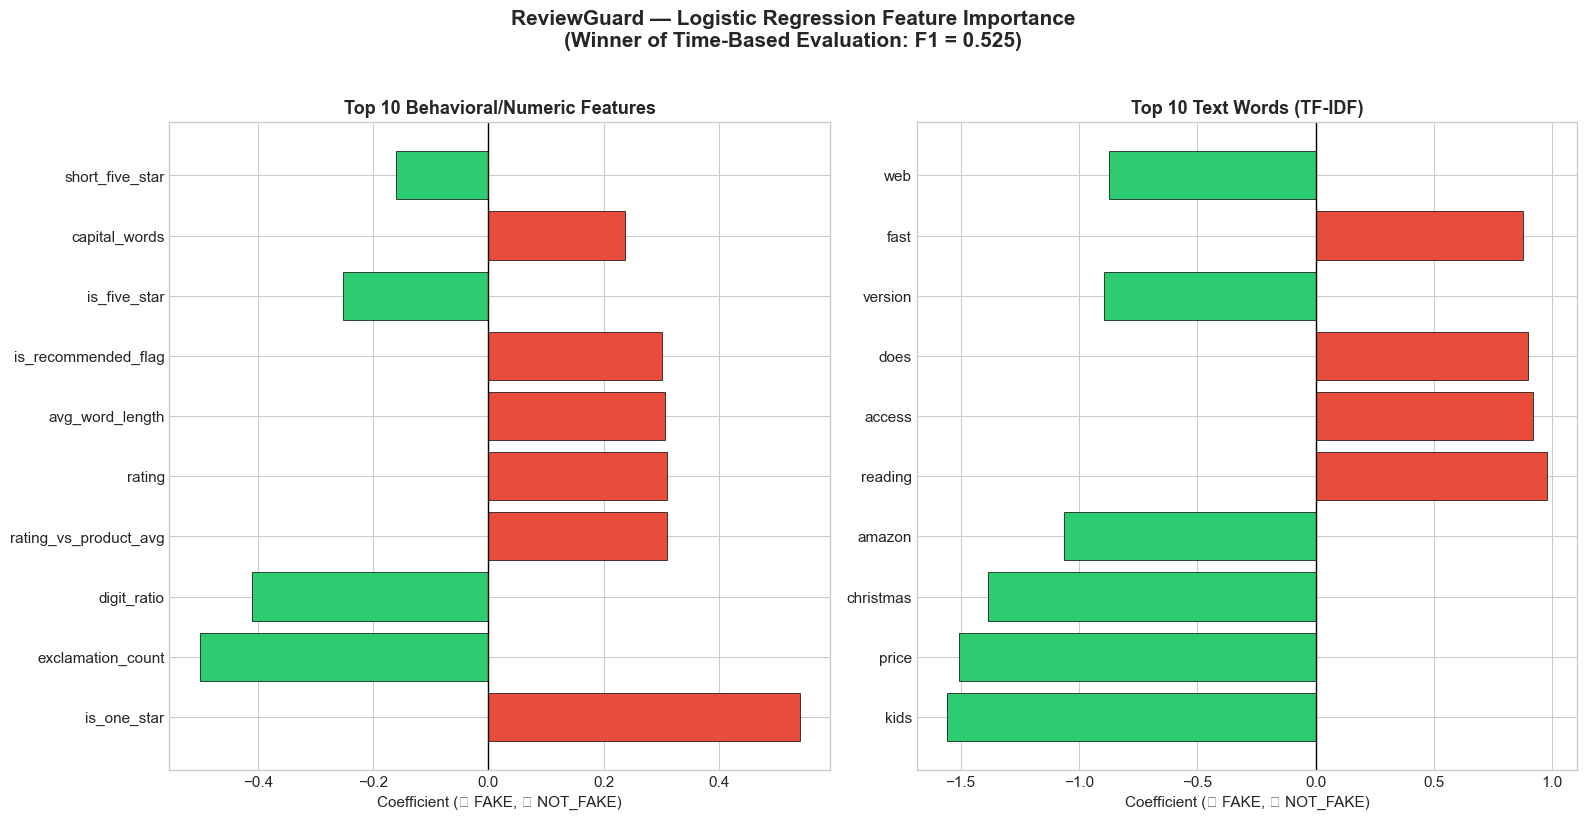


✅ Saved: outputs/ml_charts/phase3_feature_importance.png
✅ Saved: outputs/ml_charts/feature_importance.csv

  LINGUISTIC INSIGHTS FROM LOGISTIC REGRESSION

🔴 Top words associated with FAKE reviews:
   • reading              coef = +0.978
   • access               coef = +0.919
   • does                 coef = +0.897
   • fast                 coef = +0.875
   • purchase             coef = +0.840
   • old                  coef = +0.833
   • clear                coef = +0.751
   • just                 coef = +0.709
   • need                 coef = +0.536
   • user                 coef = +0.518

🟢 Top words associated with GENUINE reviews:
   • tablet               coef = -0.129
   • works                coef = -0.118
   • things               coef = -0.099
   • screen               coef = -0.088
   • fine                 coef = -0.082
   • app                  coef = -0.044
   • love                 coef = -0.043
   • library              coef = -0.025
   • perfect              coef = -0

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 7: FEATURE IMPORTANCE ANALYSIS
#  Focus on the winning model based on time-based split evaluation
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  STEP 7: FEATURE IMPORTANCE")
print("=" * 70)

# ── Identify the winning model dynamically ───────────────────────────────────
best_model_name = max(results, key=lambda x: results[x]["f1_score"])
best_model = models[best_model_name]
best_f1 = results[best_model_name]["f1_score"]

print(f"\n🏆 Winning Model: {best_model_name} (F1 = {best_f1:.3f})")
print(f"📊 Analyzing feature importance for the best performer...\n")

# ── Extract feature importance based on model type ──────────────────────────
if best_model_name == "Logistic Regression":
    # LogReg uses coefficients (sign matters: + means pushes toward FAKE, - toward NOT_FAKE)
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": best_model.coef_[0],
        "abs_coefficient": np.abs(best_model.coef_[0])
    }).sort_values("abs_coefficient", ascending=False)
    
    print(f"📊 Top 20 Most Important Features ({best_model_name}):")
    print(f"   🔴 Positive coefficient = pushes toward FAKE prediction")
    print(f"   🟢 Negative coefficient = pushes toward NOT_FAKE prediction")
    print("-" * 70)
    
    for idx, row in importance_df.head(20).iterrows():
        marker = "🔴" if row["coefficient"] > 0 else "🟢"
        bar_length = int(abs(row["coefficient"]) * 10)
        bar = "█" * min(bar_length, 15)
        print(f"   {marker}  {row['feature']:<35} {bar} {row['coefficient']:+.4f}")

elif best_model_name in ["Random Forest", "XGBoost"]:
    # Tree-based models use feature_importances_
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)
    
    print(f"📊 Top 20 Most Important Features ({best_model_name}):")
    print("-" * 70)
    
    for idx, row in importance_df.head(20).iterrows():
        bar = "█" * int(row["importance"] * 100)
        print(f"   {row['feature']:<35} {bar} {row['importance']:.4f}")

# ── Split into behavioral vs TF-IDF features ────────────────────────────────
if best_model_name == "Logistic Regression":
    numeric_imp = importance_df[~importance_df["feature"].str.startswith("tfidf_")].head(10)
    tfidf_imp = importance_df[importance_df["feature"].str.startswith("tfidf_")].head(10)
else:
    numeric_imp = importance_df[~importance_df["feature"].str.startswith("tfidf_")].head(10)
    tfidf_imp = importance_df[importance_df["feature"].str.startswith("tfidf_")].head(10)

# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Chart 1: Numeric/Behavioral features
if best_model_name == "Logistic Regression":
    colors_num = ["#e74c3c" if c > 0 else "#2ecc71" for c in numeric_imp["coefficient"]]
    axes[0].barh(numeric_imp["feature"], numeric_imp["coefficient"],
                 color=colors_num, edgecolor="black", linewidth=0.5)
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].set_xlabel("Coefficient (🔴 FAKE, 🟢 NOT_FAKE)")
else:
    axes[0].barh(numeric_imp["feature"], numeric_imp["importance"],
                 color="#3498db", edgecolor="black", linewidth=0.5)
    axes[0].set_xlabel(f"{best_model_name} Importance")

axes[0].set_title("Top 10 Behavioral/Numeric Features", fontweight="bold", fontsize=13)

# Chart 2: TF-IDF Word features
tfidf_imp_clean = tfidf_imp.copy()
tfidf_imp_clean["clean_name"] = tfidf_imp_clean["feature"].str.replace("tfidf_", "")

if best_model_name == "Logistic Regression":
    colors_word = ["#e74c3c" if c > 0 else "#2ecc71" for c in tfidf_imp_clean["coefficient"]]
    axes[1].barh(tfidf_imp_clean["clean_name"], tfidf_imp_clean["coefficient"],
                 color=colors_word, edgecolor="black", linewidth=0.5)
    axes[1].axvline(0, color="black", linewidth=1)
    axes[1].set_xlabel("Coefficient (🔴 FAKE, 🟢 NOT_FAKE)")
else:
    axes[1].barh(tfidf_imp_clean["clean_name"], tfidf_imp_clean["importance"],
                 color="#e74c3c", edgecolor="black", linewidth=0.5)
    axes[1].set_xlabel(f"{best_model_name} Importance")

axes[1].set_title("Top 10 Text Words (TF-IDF)", fontweight="bold", fontsize=13)

plt.suptitle(f"ReviewGuard — {best_model_name} Feature Importance\n"
             f"(Winner of Time-Based Evaluation: F1 = {best_f1:.3f})",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/ml_charts/phase3_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Save feature importance to CSV ──────────────────────────────────────────
importance_df.to_csv("outputs/ml_charts/feature_importance.csv", index=False)
print(f"\n✅ Saved: outputs/ml_charts/phase3_feature_importance.png")
print(f"✅ Saved: outputs/ml_charts/feature_importance.csv")

# ── Print interpretation ────────────────────────────────────────────────────
print(f"\n" + "=" * 70)
print(f"  LINGUISTIC INSIGHTS FROM {best_model_name.upper()}")
print(f"=" * 70)

if best_model_name == "Logistic Regression":
    fake_words = importance_df[
        (importance_df["feature"].str.startswith("tfidf_")) & 
        (importance_df["coefficient"] > 0)
    ].head(10)
    
    genuine_words = importance_df[
        (importance_df["feature"].str.startswith("tfidf_")) & 
        (importance_df["coefficient"] < 0)
    ].tail(10)
    
    print(f"\n🔴 Top words associated with FAKE reviews:")
    for _, row in fake_words.iterrows():
        word = row["feature"].replace("tfidf_", "")
        print(f"   • {word:<20} coef = +{row['coefficient']:.3f}")
    
    print(f"\n🟢 Top words associated with GENUINE reviews:")
    for _, row in genuine_words.iterrows():
        word = row["feature"].replace("tfidf_", "")
        print(f"   • {word:<20} coef = {row['coefficient']:.3f}")

print(f"""

📊 KEY INTERPRETATION:
The winning {best_model_name} model uses these features to predict fake reviews.
This aligns with linguistic deception research: fake reviews tend to use
generic emotional language, while genuine reviews reference specific 
context, actions, and details from actual product experience.
""")

  STEP 7: FEATURE IMPORTANCE

📊 Top 20 Most Important Features (XGBoost):
----------------------------------------------------------------------
   tfidf_watching                      █████ 0.0560
   tfidf_device                        █████ 0.0508
   tfidf_features                      ████ 0.0439
   tfidf_great tablet                  ████ 0.0400
   tfidf_nice                          ███ 0.0383
   tfidf_tablet price                  ███ 0.0351
   tfidf_set                           ███ 0.0346
   tfidf_need                          ███ 0.0330
   tfidf_reading                       ███ 0.0313
   tfidf_kids                          ██ 0.0245
   tfidf_fast                          ██ 0.0229
   tfidf_got                           ██ 0.0223
   tfidf_app                           ██ 0.0220
   tfidf_amazon                        ██ 0.0207
   tfidf_version                       █ 0.0197
   tfidf_loves                         █ 0.0196
   tfidf_price                         █ 0.0193
   tfidf_s

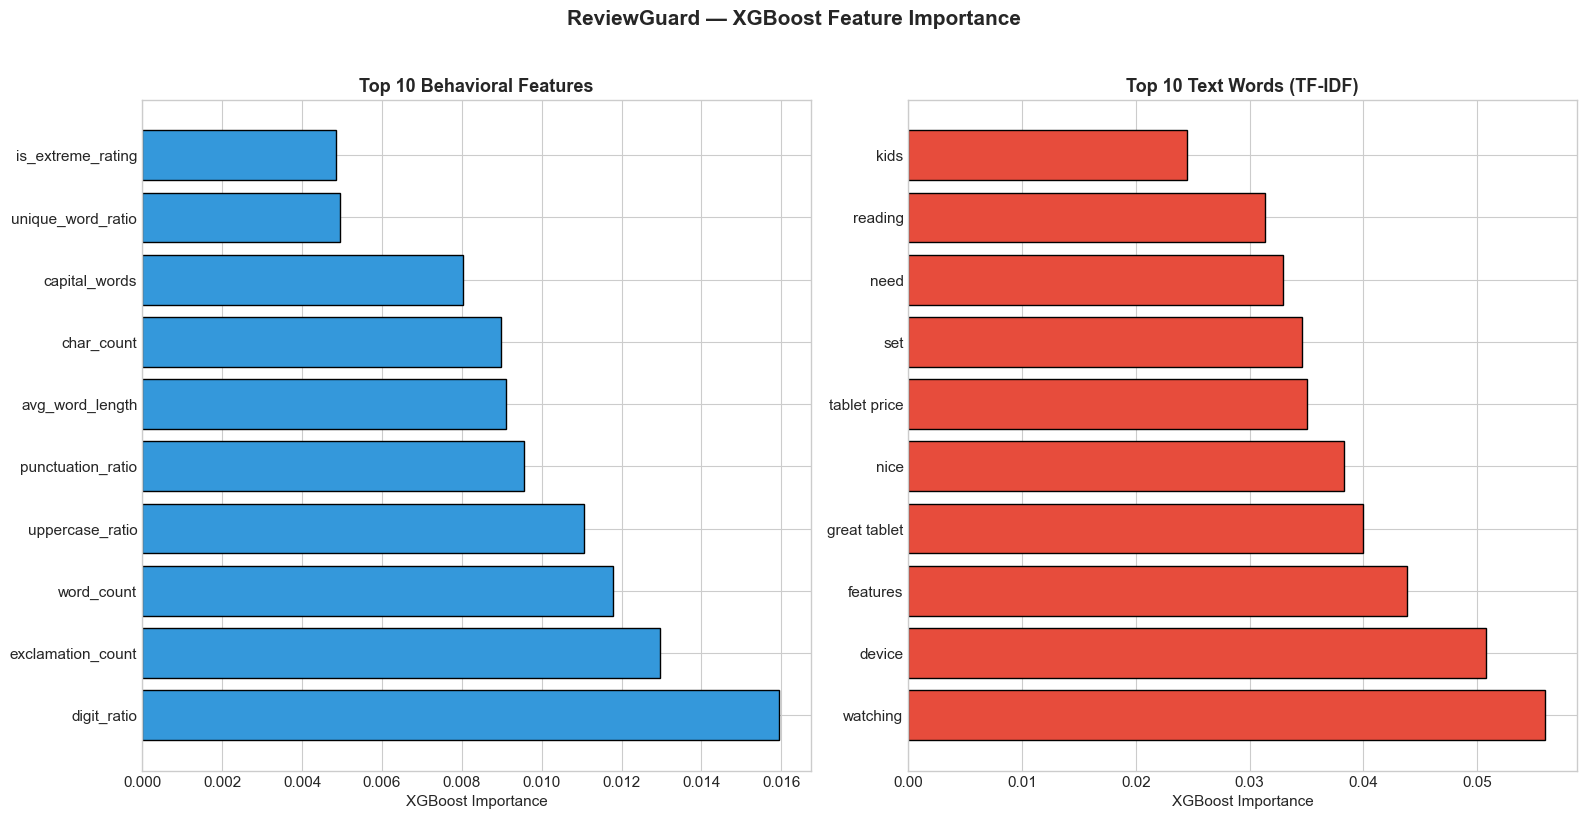


✅ Saved: outputs/ml_charts/phase3_feature_importance.png


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 7: FEATURE IMPORTANCE (XGBoost - the winner)
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  STEP 7: FEATURE IMPORTANCE")
print("=" * 70)

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(f"\n📊 Top 20 Most Important Features (XGBoost):")
print("-" * 70)
for idx, row in xgb_importance.head(20).iterrows():
    bar = "█" * int(row["importance"] * 100)
    print(f"   {row['feature']:<35} {bar} {row['importance']:.4f}")

# Split into behavioral vs TF-IDF
numeric_imp = xgb_importance[~xgb_importance["feature"].str.startswith("tfidf_")].head(10)
tfidf_imp = xgb_importance[xgb_importance["feature"].str.startswith("tfidf_")].head(10)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(numeric_imp["feature"], numeric_imp["importance"],
             color="#3498db", edgecolor="black")
axes[0].set_title("Top 10 Behavioral Features", fontweight="bold", fontsize=13)
axes[0].set_xlabel("XGBoost Importance")

tfidf_imp_clean = tfidf_imp.copy()
tfidf_imp_clean["feature"] = tfidf_imp_clean["feature"].str.replace("tfidf_", "")
axes[1].barh(tfidf_imp_clean["feature"], tfidf_imp_clean["importance"],
             color="#e74c3c", edgecolor="black")
axes[1].set_title("Top 10 Text Words (TF-IDF)", fontweight="bold", fontsize=13)
axes[1].set_xlabel("XGBoost Importance")

plt.suptitle("ReviewGuard — XGBoost Feature Importance",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/ml_charts/phase3_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

xgb_importance.to_csv("outputs/ml_charts/feature_importance.csv", index=False)
print(f"\n✅ Saved: outputs/ml_charts/phase3_feature_importance.png")

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 8: SAVE MODELS FOR PHASE 4
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  STEP 8: SAVING MODELS")
print("=" * 70)

for name, model in models.items():
    filename = f"models/phase3_{name.lower().replace(' ', '_')}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(model, f)
    print(f"✅ Saved: {filename}")

with open("models/feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)
print(f"✅ Saved: models/feature_names.pkl")

print(f"\n📊 All model files:")
for f in os.listdir("models"):
    size_kb = os.path.getsize(f"models/{f}") / 1024
    print(f"   {f}: {size_kb:.1f} KB")

  STEP 8: SAVING MODELS
✅ Saved: models/phase3_logistic_regression.pkl
✅ Saved: models/phase3_random_forest.pkl
✅ Saved: models/phase3_xgboost.pkl
✅ Saved: models/feature_names.pkl

📊 All model files:
   feature_names.pkl: 1.9 KB
   numeric_features.pkl: 0.5 KB
   phase3_logistic_regression.pkl: 3.7 KB
   phase3_random_forest.pkl: 953.4 KB
   phase3_xgboost.pkl: 285.3 KB
   scaler.pkl: 1.6 KB
   tfidf_vectorizer.pkl: 4.2 KB
